## Aproximación por serie de Taylor de $f(x) = x^{-3}(\sin x - x)$

### Derivación

Partiendo de la serie de Taylor del seno:
$\sin x = \sum_{i=0}^{\infty} \frac{(-1)^i\, x^{2i+1}}{(2i+1)!}$

Se tiene que:
$\sin x - x = \sum_{i=1}^{\infty} \frac{(-1)^i\, x^{2i+1}}{(2i+1)!}$

Dividiendo por $x^3$ (con $x \neq 0$) y reindexando con $j = i - 1$:

$f(x) = x^{-3}(\sin x - x) = \sum_{j=0}^{\infty} \frac{(-1)^{j+1}\, x^{2j}}{(2j+3)!} = -\frac{1}{3!} + \frac{x^2}{5!} - \frac{x^4}{7!} + \cdots$

Además podemos evitar el caso en que $x = 0$ eliminando analíticamente ese término del denominador. De esta forma la serie converge para todo $x$ y es bien comportada cerca del origen.

### Recurrencia entre términos consecutivos

Siendo $t_j = \dfrac{(-1)^{j+1}\, x^{2j}}{(2j+3)!}$:

$t_{j+1} = t_j \cdot \frac{-x^2}{(2j+5)(2j+4)}$

Con `denom` $= 2j + 5$ (arranca en 5, incrementa de 2 en 2):

$t_{\text{new}} = t_{\text{prev}} \cdot \frac{-x^2}{\texttt{denom} \cdot (\texttt{denom} - 1)}$

Esto evita calcular potencias y factoriales desde cero en cada paso.

### Implementación — con precisión configurable

La función `f_aprox(x, tol, precision)` acepta un string de precisión:
- `"Float16"` → 16 bits (~3 dígitos decimales, épsilon de máquina ≈ 4.88e-4)
- `"Float32"` → 32 bits (~7 dígitos decimales, épsilon de máquina ≈ 1.19e-7)
- `"Float64"` → 64 bits (~15 dígitos decimales, épsilon de máquina ≈ 2.22e-16)

**Todos** los cálculos internos (constantes, acumuladores, operaciones) se realizan
en el tipo indicado, de modo que los errores de redondeo y representación son
exactamente los propios de esa aritmética.

In [1]:
"""
Aproxima f(x) = x⁻³·(sin(x) - x) mediante la serie alternada de Taylor:
f(x)= Σ_{j=0}^{∞}  (-1)^{j+1} · x^{2j} / (2j+3)!
    = -1/3! + x²/5! - x⁴/7! + ...

usamos recurrencia entre términos consecutivos (usamos los terminos anteriormente calculados).
Nota: `precision` es un string con el tipo flotante a usar: "Float32" o "Float64"
"""
# Todos los cálculos internos se realizan en el tipo especificado, por lo que
# los errores de redondeo y representación son los propios de esa aritmética.
function f_aprox(a, tol, precision="Float64", max_iterations = 1000)

    # Seleccionamos el tipo numérico según el string que indica la precisión
    T = if precision == "Float32"
            Float32
        elseif precision == "Float64"
            Float64
        else
            error("Precisión no reconocida: '$precision'. Usa \"Float32\" o \"Float64\".")
        end

    # Convertimos los grados a radianes en la precisión parametrizada (T)
    x = T(a) / (T(180) / T(pi))

    # Convertimos las constantes y la entrada a la presición parametrizada (T)
    x_cuad = x ^ T(2)
    # primer término t_0 = -1/3! = -1/6  en precisión T 
    term = T(-1) / T(6)
    # res es el lugar donde iremos "acumulando" los términos 
    res = term
    # primer factor del denominador recurrente
    denom = T(5)
    # Expresamos la tolerancia en la misma presición
    tol_T = T(tol)

    
    converged = false
    count_iterations = 0

    for _ in 1:max_iterations
        # t_{j+1} = t_j * (−x^2) / [(denom)·(denom−1)]
        term = (-(term * x_cuad)) / (denom * (denom - T(1)))
        res  = res + term
        
        count_iterations += 1

        if abs(term) < tol_T
            converged = true
            break
        end
        
        denom = denom + T(2)
    end

    if !converged
        println("[WARNING]: Terminó por máximo de iteraciones ($max_iterations)")
    else
        println("[INFO]: Convergió en $count_iterations iteraciones")
    end

    return res, count_iterations
end


f_aprox (generic function with 3 methods)

### Tabla comparativa de resultados por precisión

Se usa [`PrettyTables.jl`](https://github.com/ronisbr/PrettyTables.jl) para mostrar en una tabla con los valores de referencia y los errores absolutos de cada precisión para los ángulos de interés.

In [2]:
# Valor de referencia en BigFloat — recibe grados, convierte a radianes
function f_ref(a)
    xb = BigFloat(a) / (BigFloat(180) / BigFloat(pi))
    (sin(xb) - xb) / xb^3
end

f_ref (generic function with 1 method)

In [3]:
import Pkg; 
Pkg.add("PrettyTables")
Pkg.status("PrettyTables")


    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


Status `~/.julia/environments/v1.12/Project.toml`
  [08abe8d2] PrettyTables v3.3.2


In [4]:
using Printf
using PrettyTables

angulos = [30, 390, 750, 1110, 1470, 1830, 2190, 2550]
tol     = 1e-6

# Calcular valores e iteraciones necesitadas
f32_val_iter = []
f64_val_iter = []

refs   = [Float64(f_ref(a)) for a in angulos]

for a in angulos    
    appr, iters = f_aprox(a, tol, "Float32")
    push!(f32_val_iter, (Float64(appr),iters))
    
    appr, iters = f_aprox(a, tol, "Float64")
    push!(f64_val_iter, (Float64(appr),iters))
end

# Obtenemos errores absolutos de cada aproximación
err32 = [abs(x[1] - r) for (x, r) in zip(f32_val_iter, refs)]
err64 = [abs(x[1] - r) for (x, r) in zip(f64_val_iter, refs)]

# Armar la tabla
data = hcat(angulos, refs, first.(f32_val_iter), first.(f64_val_iter), err32, err64)

pretty_table(
    data,
    backend       = :html,
    column_labels = [
        "Ángulo (°)", "Referencia (BigFloat)", "Float32", "Float64", "Err abs. F32", "Err abs. F64"
    ],
    formatters = [(v, i, j) -> j in 2:8 ? @sprintf("%.6e", v) : v],
    alignment  = [:r, :r, :r, :r, :r, :r],
)


[INFO]: Convergió en 3 iteraciones
[INFO]: Convergió en 3 iteraciones
[INFO]: Convergió en 11 iteraciones
[INFO]: Convergió en 11 iteraciones
[INFO]: Convergió en 18 iteraciones
[INFO]: Convergió en 18 iteraciones
[INFO]: Convergió en 26 iteraciones
[INFO]: Convergió en 26 iteraciones
[INFO]: Convergió en 34 iteraciones
[INFO]: Convergió en 34 iteraciones
[INFO]: Convergió en 43 iteraciones
[INFO]: Convergió en 43 iteraciones
[INFO]: Convergió en 51 iteraciones
[INFO]: Convergió en 51 iteraciones
[INFO]: Convergió en 59 iteraciones
[INFO]: Convergió en 59 iteraciones


Ángulo (°),Referencia (BigFloat),Float32,Float64,Err abs. F32,Err abs. F64
30.0,-1.643969e-01,-1.643969e-01,-1.643969e-01,4.619736e-09,1.412766e-10
390.0,-1.999779e-02,-1.999781e-02,-1.999778e-02,1.558293e-08,8.498868e-09
750.0,-5.613178e-03,-5.613152e-03,-5.613253e-03,2.516841e-08,7.578447e-08
1110.0,-2.595634e-03,-2.574422e-03,-2.595706e-03,2.121187e-05,7.171252e-08
1470.0,-1.489578e-03,-5.663990e-02,-1.489666e-03,5.515032e-02,8.796902e-08
1830.0,-9.649184e-04,-4.403520e+00,-9.649078e-04,4.402555e+00,1.064143e-08
2190.0,-6.755204e-04,-3.673624e+03,-6.776293e-04,3.673624e+03,2.108904e-06
2550.0,-4.991812e-04,-3.800284e+05,-2.124305e-04,3.800284e+05,2.867507e-04


### Gráfico para contrastar errores absolutos de $f(x)$
Cada grupo de barras corresponde a un valor de entrada; dentro del grupo se comparan los errores absolutos de las tres precisiones.

In [5]:
import Pkg; Pkg.add("Plots")
Pkg.status("Plots")


   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


Status `~/.julia/environments/v1.12/Project.toml`
  [91a5bcdd] Plots v1.41.6


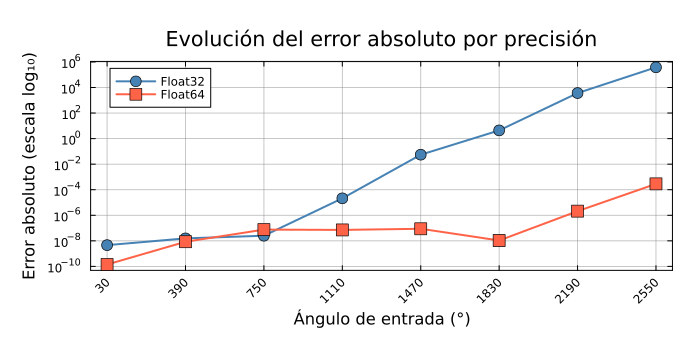

In [ ]:
using Plots
using Plots.PlotMeasures

gr()

plot(angulos, err32;
    label         = "Float32",
    color         = :steelblue,
    lw            = 2,
    marker        = :circle,
    markersize    = 5,
    yscale        = :log10,
    yticks        = [ 1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0, 1e2, 1e4, 1e6, 1e8],
    xlabel        = "Ángulo de entrada (°)",
    ylabel        = "Error absoluto (escala log₁₀)",
    title         = "\nEvolución del error absoluto por precisión",
    legend        = :topleft,
    framestyle    = :box,
    grid          = true,
    gridalpha     = 0.3,
    gridlinewidth = 0.8,
    gridcolor     = :gray,
    size = (700, 340),
    xticks        = angulos,
    xrotation     = 45,
    bottom_margin = 7mm,
    left_margin   = 7mm,
    right_margin = 5mm,
    top_margin = 7mm,

)

plot!(angulos, err64;
    label      = "Float64",
    color      = :tomato,
    lw         = 2,
    marker     = :square,
    markersize = 3,
)

### Gráfico para visualizar errores relativos por ángulo de $f(x)$
El error relativo normaliza el error absoluto respecto al valor de referencia, permitiendo comparar la precisión independientemente de la magnitud de `f(x)`.

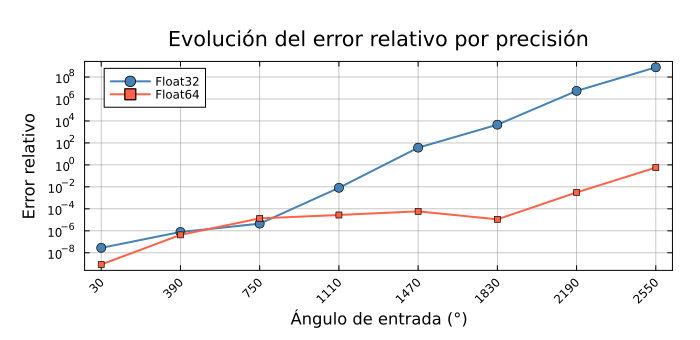

In [7]:
err32_rel = err32 ./ abs.(refs)
err64_rel = err64 ./ abs.(refs)

plot(angulos, err32_rel;
    label         = "Float32",
    color         = :steelblue,
    lw            = 2,
    marker        = :circle,
    markersize    = 5,
    yscale        = :log10,
    yticks        = [1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0, 1e2, 1e4, 1e6, 1e8, 1e10],
    xlabel        = "Ángulo de entrada (°)",
    ylabel        = "Error relativo",
    title         = "\nEvolución del error relativo por precisión",
    legend        = :topleft,
    framestyle    = :box,
    grid          = true,
    gridalpha     = 0.3,
    gridlinewidth = 0.8,
    gridcolor     = :gray,
    size = (700, 340),
    xticks        = angulos,
    xrotation     = 45,
    bottom_margin = 7mm,
    left_margin   = 7mm,
    right_margin = 5mm,
    top_margin = 7mm,
)

plot!(angulos, err64_rel;
    label      = "Float64",
    color      = :tomato,
    lw         = 2,
    marker     = :square,
    markersize = 3,
)

## Aproximación por serie de Taylor de $f(\frac{x\times \pi}{2})$
Implementamos una funcion _wrapper_ de la función previamente implementada.

In [8]:
function f_aprox_wrapper(a, tol, precision="Float64", max_iterations = 1000)
    return f_aprox((a*pi)/2, tol, precision,max_iterations)
end

f_aprox_wrapper (generic function with 3 methods)

### Tabla comparativa de resultados por precisión


In [9]:
function f_ref_w(a)
    xb = BigFloat(a) / (BigFloat(180) / BigFloat(pi))
    (sin(xb) - xb)*pi / ((xb^3)*2)
end

f_ref_w (generic function with 1 method)

In [10]:
using Printf
using PrettyTables

angulos = [30, 390, 750, 1110, 1470, 1830, 2190, 2550]
tol     = 1e-6

# Calcular valores e iteraciones necesitadas
f32_val_iter = []
f64_val_iter = []

refs   = [Float64(f_ref_w(a)) for a in angulos]

for a in angulos    
    appr, iters = f_aprox_wrapper(a, tol, "Float32")
    push!(f32_val_iter, (Float64(appr),iters))
    
    appr, iters = f_aprox_wrapper(a, tol, "Float64")
    push!(f64_val_iter, (Float64(appr),iters))
end

# Obtenemos errores absolutos de cada aproximación
err32 = [abs(x[1] - r) for (x, r) in zip(f32_val_iter, refs)]
err64 = [abs(x[1] - r) for (x, r) in zip(f64_val_iter, refs)]

# Armar la tabla
data = hcat(angulos, refs, first.(f32_val_iter), first.(f64_val_iter), err32, err64)

pretty_table(
    data,
    backend       = :html,
    column_labels = [
        "Ángulo (°)", "Referencia (BigFloat)", "Float32", "Float64", "Err abs. F32", "Err abs. F64"
    ],
    formatters = [(v, i, j) -> j in 2:8 ? @sprintf("%.6e", v) : v],
    alignment  = [:r, :r, :r, :r, :r, :r],
)


[INFO]: Convergió en 3 iteraciones
[INFO]: Convergió en 3 iteraciones
[INFO]: Convergió en 15 iteraciones
[INFO]: Convergió en 15 iteraciones
[INFO]: Convergió en 28 iteraciones
[INFO]: Convergió en 28 iteraciones
[INFO]: Convergió en 41 iteraciones
[INFO]: Convergió en 41 iteraciones
[INFO]: Convergió en 54 iteraciones
[INFO]: Convergió en 54 iteraciones
[INFO]: Convergió en 67 iteraciones
[INFO]: Convergió en 67 iteraciones
[INFO]: Convergió en 80 iteraciones
[INFO]: Convergió en 80 iteraciones
[INFO]: Convergió en 93 iteraciones
[INFO]: Convergió en 93 iteraciones


Ángulo (°),Referencia (BigFloat),Float32,Float64,Err abs. F32,Err abs. F64
30.0,-2.582340e-01,-1.611195e-01,-1.611195e-01,9.711451e-02,9.711453e-02
390.0,-3.141246e-02,-9.527897e-03,-9.527994e-03,2.188456e-02,2.188446e-02
750.0,-8.817159e-03,-2.193038e-03,-2.251421e-03,6.624121e-03,6.565738e-03
1110.0,-4.077212e-03,2.369899e+00,-1.109390e-03,2.373976e+00,2.967822e-03
1470.0,-2.339824e-03,-5.132438e+02,-5.996798e-04,5.132415e+02,1.740144e-03
1830.0,-1.515690e-03,-1.494974e+08,-1.909114e-01,1.494974e+08,1.893958e-01
2190.0,-1.061105e-03,-2.494722e+12,2.504978e+01,2.494722e+12,2.505084e+01
2550.0,-7.841120e-04,-2.068552e+16,3.638214e+07,2.068552e+16,3.638214e+07


### Gráfico para contrastar errores absolutos de $f(\frac{x \times \pi}{2})$
Cada grupo de barras corresponde a un valor de entrada; dentro del grupo se comparan los errores absolutos de las tres precisiones.

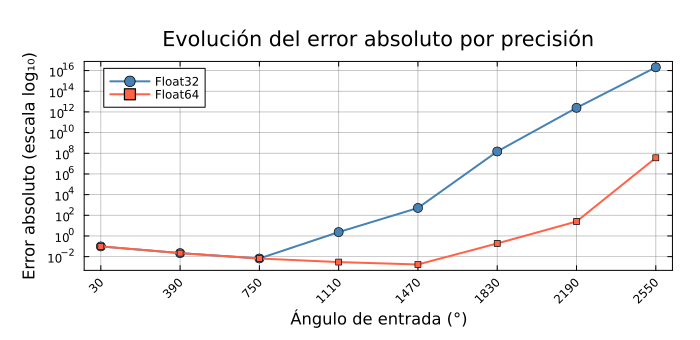

In [11]:
using Plots
using Plots.PlotMeasures

gr()

plot(angulos, err32;
    label         = "Float32",
    color         = :steelblue,
    lw            = 2,
    marker        = :circle,
    markersize    = 5,
    yscale        = :log10,
    yticks        = [ 1e-4, 1e-2, 1e0, 1e2, 1e4, 1e6, 1e8, 1e10, 1e12, 1e14, 1e16, 1e18],
    xlabel        = "Ángulo de entrada (°)",
    ylabel        = "Error absoluto (escala log₁₀)",
    title         = "\nEvolución del error absoluto por precisión",
    legend        = :topleft,
    framestyle    = :box,
    grid          = true,
    gridalpha     = 0.3,
    gridlinewidth = 0.8,
    gridcolor     = :gray,
    size = (700, 340),
    xticks        = angulos,
    xrotation     = 45,
    bottom_margin = 7mm,
    left_margin   = 7mm,
    right_margin = 5mm,
    top_margin = 7mm,

)

plot!(angulos, err64;
    label      = "Float64",
    color      = :tomato,
    lw         = 2,
    marker     = :square,
    markersize = 3,
)

### Gráfico para visualizar errores relativos por ángulo de $f(\frac{x. \pi}{2})$
El error relativo normaliza el error absoluto respecto al valor de referencia, permitiendo comparar la precisión independientemente de la magnitud de $f(\frac{x. \pi}{2})$.

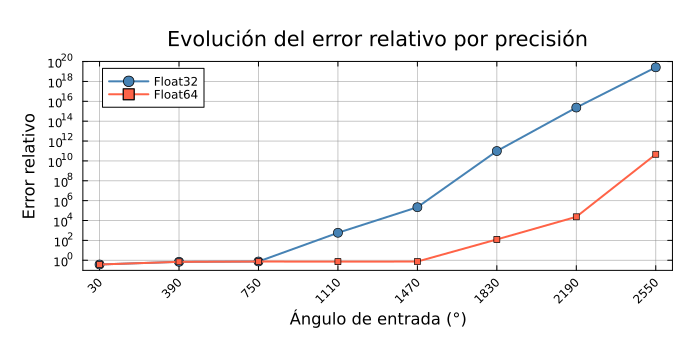

In [12]:
err32_rel = err32 ./ abs.(refs)
err64_rel = err64 ./ abs.(refs)

plot(angulos, err32_rel;
    label         = "Float32",
    color         = :steelblue,
    lw            = 2,
    marker        = :circle,
    markersize    = 5,
    yscale        = :log10,
    yticks        = [ 1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0, 1e2, 1e4, 1e6, 1e8, 1e10, 1e12, 1e14, 1e16, 1e18, 1e20],
    xlabel        = "Ángulo de entrada (°)",
    ylabel        = "Error relativo",
    title         = "\nEvolución del error relativo por precisión",
    legend        = :topleft,
    framestyle    = :box,
    grid          = true,
    gridalpha     = 0.3,
    gridlinewidth = 0.8,
    gridcolor     = :gray,
    size = (700, 340),
    xticks        = angulos,
    xrotation     = 45,
    bottom_margin = 7mm,
    left_margin   = 7mm,
    right_margin = 5mm,
    top_margin = 7mm,
)

plot!(angulos, err64_rel;
    label      = "Float64",
    color      = :tomato,
    lw         = 2,
    marker     = :square,
    markersize = 3,
)